In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("big_movement_predictions.csv")

In [ ]:
options = {}

In [ ]:
df['datetime'] = pd.to_datetime(df['ts_epoch'], unit='s').dt.tz_localize('UTC').dt.tz_convert('America/New_York')

In [ ]:
import datetime

def dateStrike2opt(edate, callPut, strike, useSPX=False):
    # Try parsing the date with multiple formats
    for fmt in ("%m/%d/%Y", "%Y-%m-%d"):
        try:
            dtd = datetime.datetime.strptime(edate, fmt)
            break
        except ValueError:
            continue
    else:
        raise ValueError(f"Date '{edate}' does not match expected formats.")
    
    blah = "O:SPY"
    if useSPX:
        blah = "O:SPXW"
    option = blah + dtd.strftime("%y%m%d") + callPut + str(strike).zfill(5) + "000"
    return option

In [117]:
from massive import RESTClient
import os
client = RESTClient(os.environ.get("polygon_api_key"))

def get_option(option_ticker, date):
    
    aggs = []
    for a in client.list_aggs(
    option_ticker,
    1,
    "minute",
    date,
    pd.to_datetime(date) + datetime.timedelta(days=1),
    adjusted="true",
    sort="asc",
    limit=500000,
    ):
        aggs.append(a)
    if len(aggs) == 0:
        return None
    option_df = pd.DataFrame(aggs)
    option_df['datetime'] = pd.to_datetime(option_df['timestamp'], unit='ms', utc=True).dt.tz_convert('America/New_York')
    return option_df

In [129]:
test_df = df[df['pred_prob'] >= .33]
test_df = df[df['datetime'].dt.date > pd.to_datetime("2023-01-01").date()]

In [135]:
rets = []
missing_count = {}
for k, v in test_df.groupby('date'):
    day_miss_count = 0
    cooldown_timer = None
    for i in range(len(v)):
        row = v.iloc[i]
        if cooldown_timer is not None and row['datetime'] < cooldown_timer:
            continue
        if row['datetime'].time() > pd.to_datetime('15:28').time():
            continue
        if row['pred_prob'] >= 0.5:
            call_option = dateStrike2opt(row['date'], 'C', int(row['c'])+2)
            put_option = dateStrike2opt(row['date'], 'P', int(row['c'])-2)
            if call_option not in options:
                options[call_option] = get_option(call_option, row['date'])
            if put_option not in options:
                options[put_option] = get_option(put_option, row['date'])
            call_option_data = options[call_option]
            put_option_data = options[put_option]
            if call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)].empty or put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)].empty:
                print(f"Missing exit data for {call_option} or {put_option} on {row['datetime']}")
                missing_count[k] = missing_count.get(k, 0) + 1
                continue
            curr_trade = {
                'entry_time': row['datetime'],
                'call_entry_price': call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=1)]['open'].values[0] if not call_option_data.empty else None,
                'put_entry_price': put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=1)]['open'].values[0] if not put_option_data.empty else None,
                'call_exit_price': call_option_data[call_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)]['close'].values[0] if not call_option_data.empty else None,
                'put_exit_price': put_option_data[put_option_data['datetime'] >= row['datetime'] + datetime.timedelta(minutes=30)]['close'].values[0] if not put_option_data.empty else None,
            }
            trade_ret = {
            'call_return': (curr_trade['call_exit_price'] - curr_trade['call_entry_price']) / curr_trade['call_entry_price'] if curr_trade['call_entry_price'] is not None and curr_trade['call_exit_price'] is not None else None,
            'put_return': (curr_trade['put_exit_price'] - curr_trade['put_entry_price']) / curr_trade['put_entry_price'] if curr_trade['put_entry_price'] is not None and curr_trade['put_exit_price'] is not None else None,
            }
            print("total return: ", trade_ret['call_return'] + trade_ret['put_return'])

            cooldown_timer = row['datetime'] + pd.Timedelta(minutes=31)
            rets.append(curr_trade)
    

total return:  -0.7083333333333333
total return:  1.469767441860465
total return:  1.8383838383838382
total return:  0.10606060606060608
total return:  0.0117647058823529
total return:  -0.2140350877192983
total return:  1.2397397397397403
total return:  -0.37459389213775196
total return:  -0.43845663265306123
total return:  -0.2545454545454546
total return:  0.5279069767441862
total return:  2.435185185185185
total return:  2.0926686217008794
total return:  -0.65
total return:  1.7384615384615385
total return:  -0.6170977011494252
total return:  -0.682615629984051
total return:  -1.25
total return:  0.8282608695652173
total return:  -0.6136363636363638
total return:  -0.6117424242424243
total return:  -0.27666666666666667
total return:  -0.3281210592686002
total return:  -0.3359497645211932
total return:  -0.5153358011634055
total return:  -1.021311475409836
total return:  -0.3042242400315831
total return:  -0.7687569988801791
total return:  -1.0961538461538463
total return:  -0.15956

In [136]:
ret_df = pd.DataFrame(rets)
ret_df

,entry_time,call_entry_price,put_entry_price,call_exit_price,put_exit_price
0,2023-01-03 14:47:00-05:00,0.24,0.12,0.23,0.04
1,2023-01-04 14:00:00-05:00,0.43,0.45,0.03,1.53
2,2023-01-04 14:31:00-05:00,0.33,0.18,1.23,0.02
3,2023-01-09 14:00:00-05:00,0.33,0.06,0.20,0.09
4,2023-01-23 14:47:00-05:00,0.34,0.10,0.65,0.01
...,...,...,...,...,...
303,2025-11-19 12:45:00-05:00,1.45,1.33,1.93,0.72
304,2025-11-20 11:54:00-05:00,2.10,2.30,1.27,4.40
305,2025-11-20 12:25:00-05:00,2.84,2.35,2.00,2.12
306,2025-11-21 13:52:00-05:00,1.20,0.72,1.47,0.24


In [ ]:
from massive import RESTClient
import os
client = RESTClient(os.environ.get("polygon_api_key"))
def get_vix(date):
    
    aggs = []
    for a in client.list_aggs(
    'I:VIX',
    1,
    "minute",
    '2023-01-01',
    '2025-12-31',
    adjusted="true",
    sort="asc",
    limit=500000,
    ):
        aggs.append(a)
    if len(aggs) == 0:
        return None
    vix_df = pd.DataFrame(aggs)
    vix_df['datetime'] = pd.to_datetime(vix_df['timestamp'], unit='ms', utc=True).dt.tz_convert('America/New_York')
    return vix_df

In [99]:
ret_df['call_return'] = (ret_df['call_exit_price'] - ret_df['call_entry_price']) / ret_df['call_entry_price']
ret_df['put_return'] = (ret_df['put_exit_price'] - ret_df['put_entry_price']) / ret_df['put_entry_price']
ret_df['total_return'] = ret_df['call_return'] + ret_df['put_return']
ret_df

,entry_time,call_entry_price,put_entry_price,call_exit_price,put_exit_price,call_return,put_return,total_return
0,2023-01-03 14:47:00-05:00,0.24,0.12,0.23,0.04,-0.041667,-0.666667,-0.708333
1,2023-01-04 14:00:00-05:00,0.43,0.45,0.03,1.53,-0.930233,2.400000,1.469767
2,2023-01-04 14:31:00-05:00,0.33,0.18,1.23,0.02,2.727273,-0.888889,1.838384
3,2023-01-09 14:00:00-05:00,0.33,0.06,0.20,0.09,-0.393939,0.500000,0.106061
4,2023-01-23 14:47:00-05:00,0.34,0.10,0.65,0.01,0.911765,-0.900000,0.011765
...,...,...,...,...,...,...,...,...
303,2025-11-19 12:45:00-05:00,1.45,1.33,1.93,0.72,0.331034,-0.458647,-0.127612
304,2025-11-20 11:54:00-05:00,2.10,2.30,1.27,4.40,-0.395238,0.913043,0.517805
305,2025-11-20 12:25:00-05:00,2.84,2.35,2.00,2.12,-0.295775,-0.097872,-0.393647
306,2025-11-21 13:52:00-05:00,1.20,0.72,1.47,0.24,0.225000,-0.666667,-0.441667


In [103]:
ret_df['put_return'].mean()

np.float64(0.1257868257052575)

In [105]:
ret_df['put_return'].sum()

np.float64(38.74234231721931)

In [106]:
ret_df['call_return'].sum()

np.float64(-8.754905839489172)

In [104]:
ret_df['call_return'].mean()

np.float64(-0.02842501895938043)

In [101]:
ret_df['total_return'].mean()

np.float64(0.09736180674587709)

In [111]:
ret_df['total_return'].describe()

count    308.000000
mean       0.097362
std        2.518351
min       -1.500000
25%       -0.625633
50%       -0.316825
75%        0.115392
max       32.883333
Name: total_return, dtype: float64

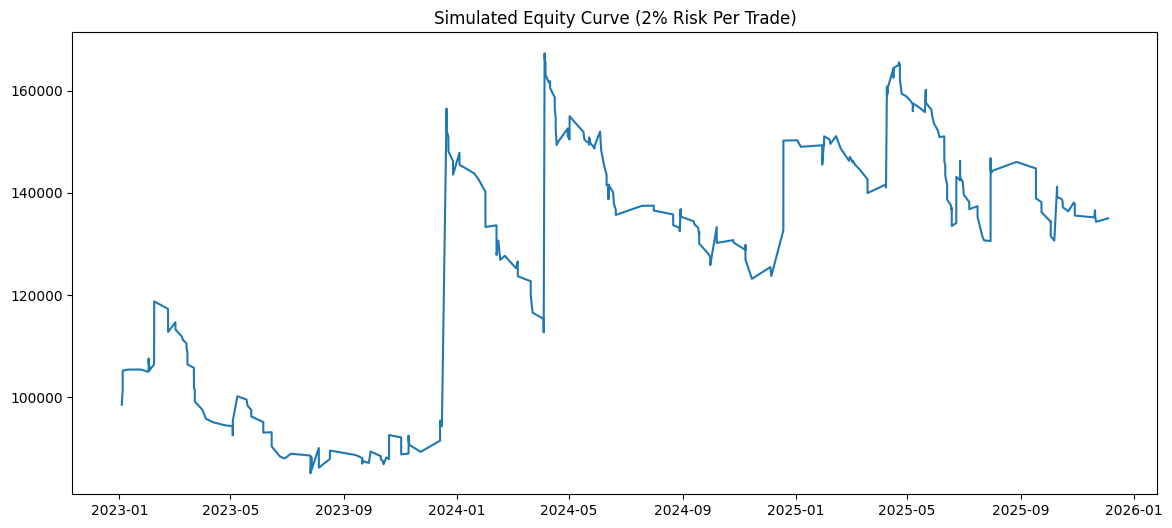

Final Capital: 135036.84541417006
Total Return: 0.3503684541417007
Sharpe: 0.03958065992438234
Max Drawdown: -0.28301233702814743


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ret_df = ret_df.copy()
ret_df['entry_time'] = pd.to_datetime(ret_df['entry_time'])
ret_df = ret_df.sort_values('entry_time').reset_index(drop=True)

# --- PARAMETERS ---
initial_capital = 100000
risk_fraction = 0.02   # 2% of capital per trade

capital = initial_capital
equity_curve = []

for r in ret_df['total_return']:
    position_size = capital * risk_fraction
    pnl = position_size * r
    capital += pnl
    equity_curve.append(capital)

ret_df['equity'] = equity_curve

# --- Portfolio Returns ---
ret_df['portfolio_return'] = ret_df['equity'].pct_change().fillna(0)
ret_df['cum_return'] = ret_df['equity'] / initial_capital

# --- Metrics ---
mean_ret = ret_df['portfolio_return'].mean()
vol = ret_df['portfolio_return'].std()
sharpe = mean_ret / vol if vol != 0 else np.nan

rolling_max = ret_df['equity'].cummax()
drawdown = ret_df['equity'] / rolling_max - 1
max_dd = drawdown.min()

# --- Plot ---
plt.figure(figsize=(14,6))
plt.plot(ret_df['entry_time'], ret_df['equity'])
plt.title("Simulated Equity Curve (2% Risk Per Trade)")
plt.show()

print("Final Capital:", capital)
print("Total Return:", capital/initial_capital - 1)
print("Sharpe:", sharpe)
print("Max Drawdown:", max_dd)


In [116]:
(df['c'].iloc[-1] - df['c'].iloc[0]) / df['c'].iloc[0]

np.float64(0.8228583613198996)